In [1]:
# ============================================================
# CELL 1: Import only required libraries for Ridge Regression
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Ridge Regression model
from sklearn.linear_model import Ridge

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split, cross_val_score, KFold
)

# Evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Pipeline (optional but useful)
from sklearn.pipeline import Pipeline

import joblib   # to save/load the trained model

print('Libraries for Ridge Regression imported successfully!')

Libraries for Ridge Regression imported successfully!


In [2]:
# ============================================================
# CELL 2: Load Dataset
# ============================================================

# Load the Excel file — change the filename/path if needed
df = pd.read_excel('2nd-efficiency-percentage.xlsx')

print('Dataset shape:', df.shape)
print('\nColumn names:')
print(df.columns.tolist())
print('\nFirst 5 rows:')
df.head()

Dataset shape: (204, 20)

Column names:
['Date', 'solvent to leach flow ratio', 'leach solution sec-1', 'leach solution sec-2', 'leach Acidity', 'leach Fe', 'leach pH', 'leach Cu', 'lean Cu conc', 'lean Fe conc', 'lean H2SO4', 'Aqueous Flow', 'Organic Flow', 'Phase engagement time', 'lean Flow', 'Cu conc in raffinate sec-1', 'Cu conc in raffinate sec-2', 'Extraction percentage', 'Input Copper', 'Output Copper']

First 5 rows:


,Date,solvent to leach flow ratio,leach solution sec-1,leach solution sec-2,leach Acidity,leach Fe,leach pH,leach Cu,lean Cu conc,lean Fe conc,lean H2SO4,Aqueous Flow,Organic Flow,Phase engagement time,lean Flow,Cu conc in raffinate sec-1,Cu conc in raffinate sec-2,Extraction percentage,Input Copper,Output Copper
0,2024-04-01,1.12,32023.85,31810.33,0,32.495000,1.573333,0.697,34.180000,6.231667,177.833333,63834.18,35627.5696,10,2878.11,0.05,0.05,92.70,64.069090,59.392046
1,2024-04-02,1.08,30919.57,30873.21,0,31.945000,1.538333,0.695,35.656667,6.401667,175.333333,61792.78,33343.0668,9,2961.71,0.06,0.05,92.09,61.842214,56.950495
2,2024-04-03,1.18,31997.43,31576.28,0,32.586667,1.540000,0.680,36.188333,6.505000,179.833333,63573.71,37260.0104,9,2918.24,0.05,0.05,93.14,62.251377,57.980932
3,2024-04-04,1.10,31979.74,31607.92,0,31.701667,1.526667,0.682,35.608333,6.741667,176.333333,63587.66,34768.7120,10,2882.76,0.06,0.06,91.20,62.448169,56.952730
4,2024-04-05,1.12,32006.92,31616.33,16,32.483333,1.490000,0.682,35.938333,6.948333,181.833333,63623.25,35410.2896,10,2639.32,0.05,0.05,92.79,62.483121,57.978088


In [3]:
# ============================================================
# CELL 3: Basic Data Exploration
# ============================================================

print('Dataset Info:')
print(df.info())
print('\nDescriptive Statistics:')
print(df.describe())
print('\nMissing Values:')
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Date                         204 non-null    datetime64[ns]
 1   solvent to leach flow ratio  204 non-null    float64       
 2   leach solution sec-1         204 non-null    float64       
 3   leach solution sec-2         204 non-null    float64       
 4   leach Acidity                204 non-null    int64         
 5   leach Fe                     204 non-null    float64       
 6   leach pH                     204 non-null    float64       
 7   leach Cu                     204 non-null    float64       
 8   lean Cu conc                 204 non-null    float64       
 9   lean Fe conc                 204 non-null    float64       
 10  lean H2SO4                   204 non-null    float64       
 11  Aqueous Flow                 20

In [4]:
# ============================================================
# CELL 4: Data Preprocessing
# NOTE: 
#   - We do NOT clip outliers (as per ma'am's instruction)
#   - We drop only 'date' column (NOT phase_engagement_time)
#   - We also ignore these columns for model INPUT:
#     'Cu conc in raffinate sec-1', 'Cu conc in raffinate sec-2',
#     'extraction_percentage', 'date'
#   - Target column: 'output_copper'
# ============================================================

# Make a copy to preserve original data
df1 = df.copy()

# Drop 'date' column directly (without condition check)
df1 = df1.drop(columns=['Date'])
print("date column dropped.")

# Handle missing values — fill with column median (robust to outliers)
numeric_cols = df1.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df1[col].isnull().sum() > 0:
        df1[col].fillna(df1[col].median(), inplace=True)
        print(f"  Filled NaN in '{col}' with median")

print('\nDataset shape after preprocessing:', df1.shape)
print('Remaining columns:', df1.columns.tolist())

date column dropped.

Dataset shape after preprocessing: (204, 19)
Remaining columns: ['solvent to leach flow ratio', 'leach solution sec-1', 'leach solution sec-2', 'leach Acidity', 'leach Fe', 'leach pH', 'leach Cu', 'lean Cu conc', 'lean Fe conc', 'lean H2SO4', 'Aqueous Flow', 'Organic Flow', 'Phase engagement time', 'lean Flow', 'Cu conc in raffinate sec-1', 'Cu conc in raffinate sec-2', 'Extraction percentage', 'Input Copper', 'Output Copper']


In [5]:
df1.columns = df1.columns.str.lower().str.replace(' ', '_')
df1.columns

Index(['solvent_to_leach_flow_ratio', 'leach_solution_sec-1',
       'leach_solution_sec-2', 'leach_acidity', 'leach_fe', 'leach_ph',
       'leach_cu', 'lean_cu_conc', 'lean_fe_conc', 'lean_h2so4',
       'aqueous_flow', 'organic_flow', 'phase_engagement_time', 'lean_flow',
       'cu_conc_in_raffinate_sec-1', 'cu_conc_in_raffinate_sec-2',
       'extraction_percentage', 'input_copper', 'output_copper'],
      dtype='object')

In [6]:
# ============================================================
# CELL 5: Feature Engineering
# This ratio helps capture the relationship between copper and iron in the leach solution, which affects extraction
# ============================================================

# We add a small epsilon to avoid division by zero
df1['cu_fe_ratio'] = df1['leach_cu'] / (df1['leach_fe'] + 1e-9)

print('cu_fe_ratio feature added.')
print('\nSample of new feature:')
print(df1[['leach_cu', 'leach_fe', 'cu_fe_ratio']].head(10))

cu_fe_ratio feature added.

Sample of new feature:
   leach_cu   leach_fe  cu_fe_ratio
0     0.697  32.495000     0.021449
1     0.695  31.945000     0.021756
2     0.680  32.586667     0.020867
3     0.682  31.701667     0.021513
4     0.682  32.483333     0.020995
5     0.702  32.935000     0.021315
6     0.720  33.085000     0.021762
7     0.722  32.840000     0.021985
8     0.703  33.351667     0.021078
9     0.692  33.391667     0.020724


In [7]:
# ============================================================
# CELL 6: Define Features (X) and Target (y)
# ============================================================

# Columns to EXCLUDE from model input
columns_to_exclude = [
    'cu_conc_in_raffinate_sec-1',
    'cu_conc_in_raffinate_sec-2',
    'extraction_percentage',
    'date',
    'output_copper'
]

# Keep only the columns that are present in the dataframe
cols_to_drop = [c for c in columns_to_exclude if c in df1.columns]

# Feature matrix X — all columns except the excluded ones
X = df1.drop(columns=cols_to_drop)

# Target vector y
y = df1['output_copper']
# y = df1['extraction_percentage']

print('Feature columns (X):', X.columns.tolist())
print('\nNumber of features:', X.shape[1])
print('Number of samples:', X.shape[0])
print('\nTarget (y) — output_copper:')
print(y.describe())

Feature columns (X): ['solvent_to_leach_flow_ratio', 'leach_solution_sec-1', 'leach_solution_sec-2', 'leach_acidity', 'leach_fe', 'leach_ph', 'leach_cu', 'lean_cu_conc', 'lean_fe_conc', 'lean_h2so4', 'aqueous_flow', 'organic_flow', 'phase_engagement_time', 'lean_flow', 'input_copper', 'cu_fe_ratio']

Number of features: 16
Number of samples: 204

Target (y) — output_copper:
count    204.000000
mean      58.173731
std        5.940090
min       36.620749
25%       55.070204
50%       58.281909
75%       61.455895
max       73.551168
Name: output_copper, dtype: float64


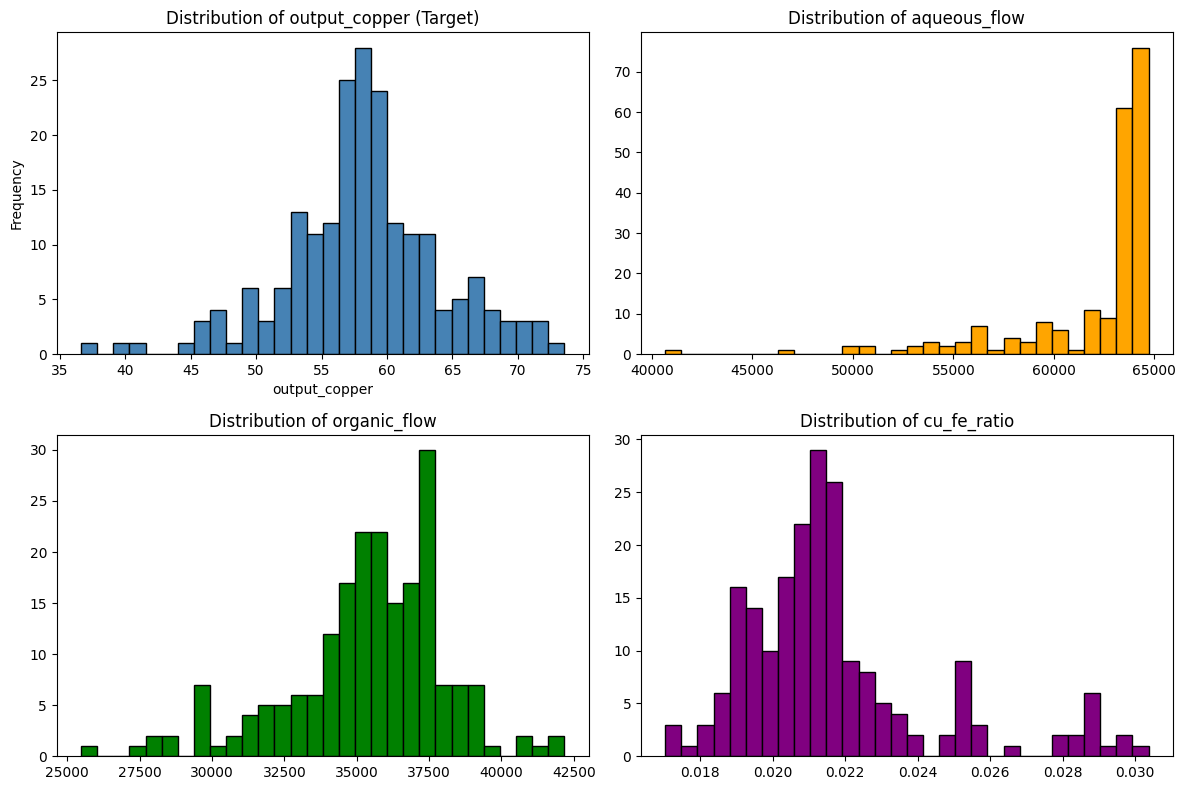

Feature distribution plots displayed.


In [8]:
# ============================================================
# CELL 7: Visualize Distributions (without clipping outliers)
# Just to understand the data spread
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Target distribution
axes[0, 0].hist(y, bins=30, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Distribution of output_copper (Target)')
axes[0, 0].set_xlabel('output_copper')
axes[0, 0].set_ylabel('Frequency')

# Aqueous flow distribution
if 'aqueous_flow' in X.columns:
    axes[0, 1].hist(X['aqueous_flow'], bins=30, color='orange', edgecolor='black')
    axes[0, 1].set_title('Distribution of aqueous_flow')

# Organic flow distribution
if 'organic_flow' in X.columns:
    axes[1, 0].hist(X['organic_flow'], bins=30, color='green', edgecolor='black')
    axes[1, 0].set_title('Distribution of organic_flow')

# cu_fe_ratio distribution
axes[1, 1].hist(df1['cu_fe_ratio'], bins=30, color='purple', edgecolor='black')
axes[1, 1].set_title('Distribution of cu_fe_ratio')

plt.tight_layout()
plt.show()

print('Feature distribution plots displayed.')

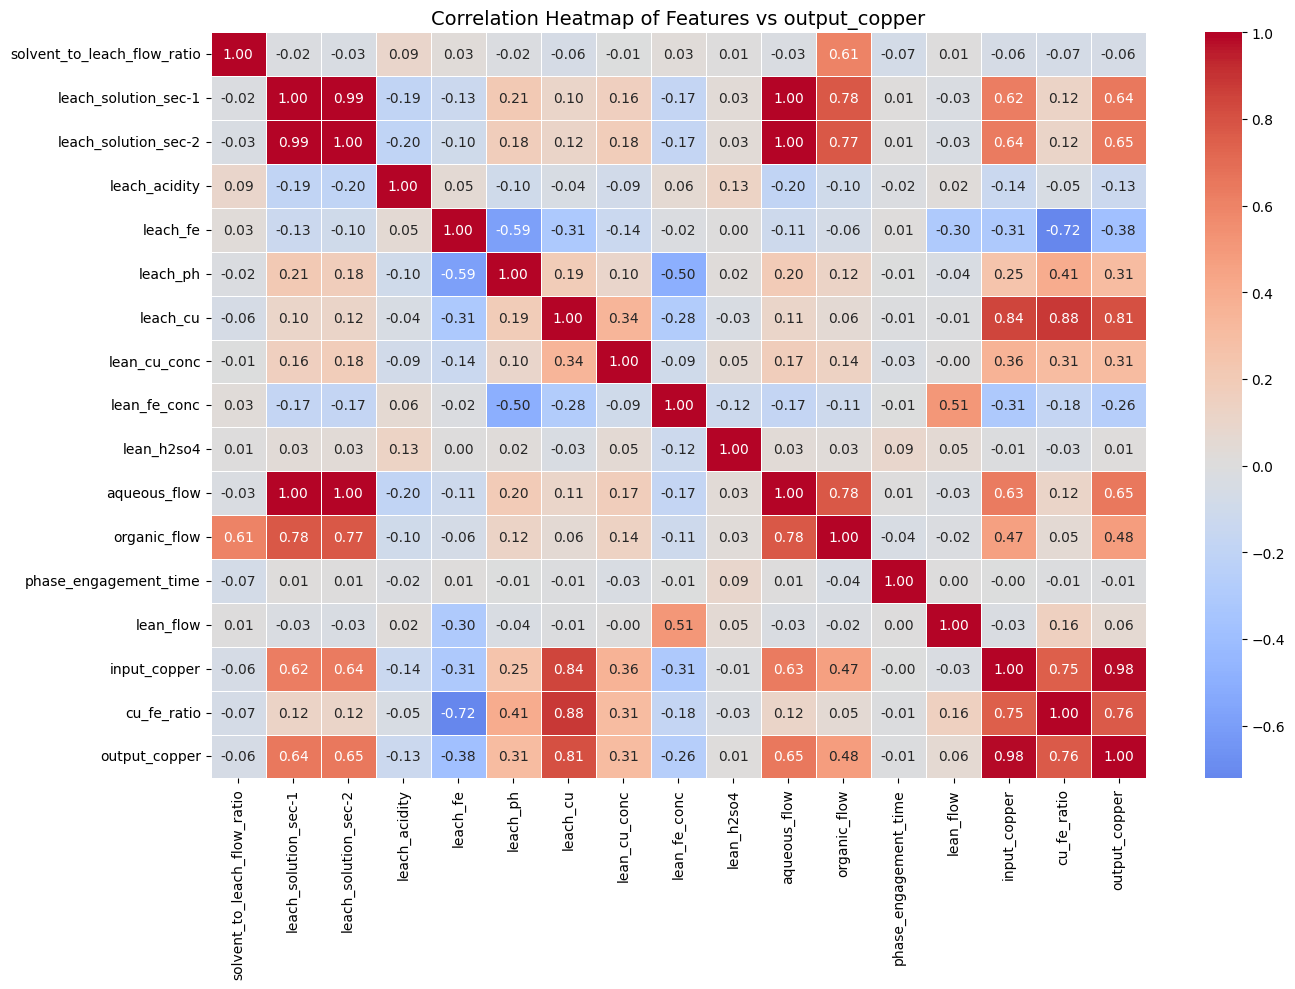

Correlation heatmap displayed.


In [9]:
# ============================================================
# CELL 8: Correlation Heatmap
# Understand which features are most correlated with output_copper
# ============================================================

plt.figure(figsize=(14, 10))
corr_df = pd.concat([X, y], axis=1)
correlation_matrix = corr_df.corr()
sns.heatmap(
    correlation_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title('Correlation Heatmap of Features vs output_copper', fontsize=14)
plt.tight_layout()
plt.show()

print('Correlation heatmap displayed.')

In [10]:
# ============================================================
# CELL 9: Train-Test Split & Scaling
# - 80% training, 20% testing
# ============================================================

# Save feature column names for later use (optimizer needs this)
feature_columns = X.columns.tolist()

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Scale features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only!
X_test_scaled = scaler.transform(X_test)          # apply same transform to test

print(f'Training set size: {X_train.shape}')
print(f'Test set size: {X_test.shape}')

Training set size: (163, 16)
Test set size: (41, 16)


In [11]:
# ============================================================
# CELL 10: Helper Function — Evaluate a Model
# This function:
#   1. Trains the model
#   2. Predicts on test set
#   3. Performs 5-fold cross validation
#   4. Prints all metrics
# ============================================================

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, use_scaled=False):
    """
    Trains and evaluates a regression model.
    
    Parameters:
        name       : Model name (string)
        model      : Sklearn-compatible model object
        X_tr       : Training features
        X_te       : Test features
        y_tr       : Training target
        y_te       : Test target
        use_scaled : If True, use scaled features (for SVR, Ridge, etc.)
    
    Returns:
        dict with model metrics
    """
    # Fit the model on training data
    model.fit(X_tr, y_tr)
    
    # Predict on test set
    y_pred = model.predict(X_te)
    
    # --- Test Set Metrics ---
    r2  = r2_score(y_te, y_pred)
    mae = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    
    # --- 5-Fold Cross Validation (on training data) ---
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=kf, scoring='r2')
    cv_mean = cv_scores.mean()
    cv_std  = cv_scores.std()
    
    # --- Train R² (to check overfitting) ---
    y_train_pred = model.predict(X_tr)
    train_r2 = r2_score(y_tr, y_train_pred)
    
    # --- NEW: Accuracy-style percentage (R² as %) ---
    train_accuracy = train_r2 * 100
    test_accuracy  = r2 * 100
    
    # --- Overfitting check ---
    overfit_gap = train_r2 - r2
    if overfit_gap > 0.15:
        fit_status = 'OVERFITTING'
    elif r2 < 0.5:
        fit_status = 'UNDERFITTING'
    else:
        fit_status = 'GOOD FIT'
    
    print(f'\n{"="*55}')
    print(f'  Model: {name}')
    print(f'{"="*55}')
    print(f'  Train R²        : {train_r2:.4f}')
    print(f'  Test  R²        : {r2:.4f}')
    
    # --- NEW: Print accuracy-style values ---
    print(f'  Train Accuracy  : {train_accuracy:.2f}%')
    print(f'  Test  Accuracy  : {test_accuracy:.2f}%')
    
    print(f'  Test  MAE       : {mae:.4f}')
    print(f'  Test  RMSE      : {rmse:.4f}')
    print(f'  CV R² (5-fold)  : {cv_mean:.4f} ± {cv_std:.4f}')
    print(f'  Overfit Gap     : {overfit_gap:.4f}')
    print(f'  Status          : {fit_status}')
    
    return {
        'model_name' : name,
        'model_obj'  : model,
        'train_r2'   : train_r2,
        'test_r2'    : r2,
        'mae'        : mae,
        'rmse'       : rmse,
        'cv_mean'    : cv_mean,
        'cv_std'     : cv_std,
        'overfit_gap': overfit_gap,
        'fit_status' : fit_status,
        'use_scaled' : use_scaled,
        
        # --- NEW: store accuracy values ---
        'train_accuracy': train_accuracy,
        'test_accuracy' : test_accuracy
    }

print('evaluate_model() function defined.')

evaluate_model() function defined.


In [12]:
# ============================================================
# Ridge uses L2 regularization to prevent overfitting
# Note: Ridge works better on scaled features
# ============================================================
from sklearn.model_selection import GridSearchCV
print('Tuning Ridge Regression...')

ridge_param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
}

ridge_search = GridSearchCV(
    estimator=Ridge(),
    param_grid=ridge_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Ridge uses SCALED features
ridge_search.fit(X_train_scaled, y_train)
print('Best Ridge alpha:', ridge_search.best_params_)

ridge_result = evaluate_model(
    'Ridge Regression (Tuned)',
    ridge_search.best_estimator_,
    X_train_scaled, X_test_scaled, y_train, y_test,
    use_scaled=True
)

# --- NEW: Explicitly print accuracy again ---
print('\nAdditional Accuracy Summary:')
print(f"Train Accuracy  : {ridge_result['train_accuracy']:.2f}%")
print(f"Test Accuracy   : {ridge_result['test_accuracy']:.2f}%")
print(f"CV Accuracy     : {ridge_result['cv_mean']*100:.2f}%")

Tuning Ridge Regression...
Best Ridge alpha: {'alpha': 0.1}

  Model: Ridge Regression (Tuned)
  Train R²        : 0.9860
  Test  R²        : 0.9762
  Train Accuracy  : 98.60%
  Test  Accuracy  : 97.62%
  Test  MAE       : 0.6215
  Test  RMSE      : 0.8920
  CV R² (5-fold)  : 0.9777 ± 0.0085
  Overfit Gap     : 0.0098
  Status          : GOOD FIT

Additional Accuracy Summary:
Train Accuracy  : 98.60%
Test Accuracy   : 97.62%
CV Accuracy     : 97.77%


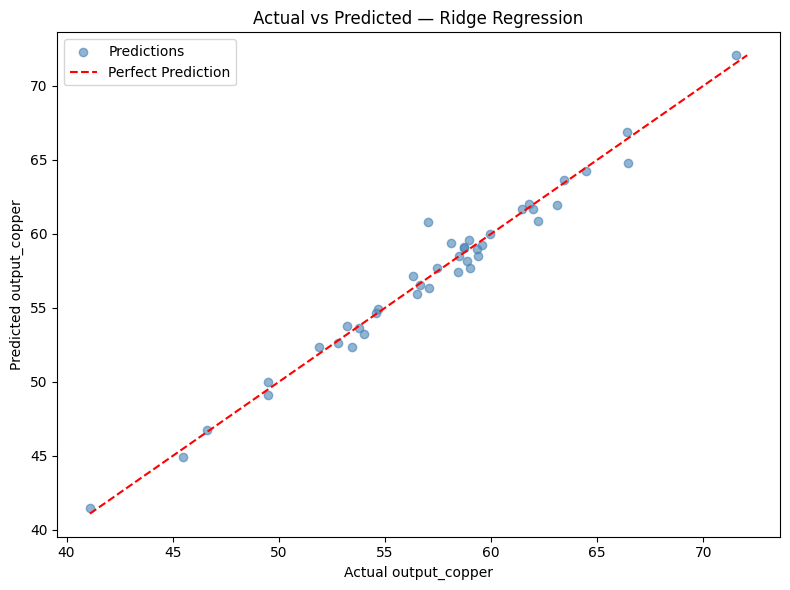

Final Test R²       : 0.9762
Final Test Accuracy: 97.62%


In [13]:
# ============================================================
# CELL 21: Actual vs Predicted Plot (Ridge Only)
# Visual check — how close are predictions to real values?
# ============================================================

# Use best Ridge model directly
best_model = ridge_search.best_estimator_

# Since Ridge uses scaled features
y_pred_best = best_model.predict(X_test_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.6, color='steelblue', label='Predictions')

# Perfect prediction line (y = x)
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')

plt.xlabel('Actual output_copper')
plt.ylabel('Predicted output_copper')
plt.title('Actual vs Predicted — Ridge Regression')
plt.legend()
plt.tight_layout()
plt.show()

# --- Metrics ---
final_r2 = r2_score(y_test, y_pred_best)
final_accuracy = final_r2 * 100

print(f'Final Test R²       : {final_r2:.4f}')
print(f'Final Test Accuracy: {final_accuracy:.2f}%')

In [14]:
# ============================================================
# Calculate Extraction Percentage (Actual vs Predicted)
# ============================================================

# Get predictions from best Ridge model
y_pred = ridge_search.best_estimator_.predict(X_test_scaled)

# Get input copper values from test set
input_cu_test = X_test['input_copper'].values

# --- Actual Extraction % ---
actual_extraction = (y_test.values / input_cu_test) * 100

# --- Predicted Extraction % ---
predicted_extraction = (y_pred / input_cu_test) * 100

# Print sample results
print("\nSample Extraction % Comparison:")
for i in range(5):
    print(f"Actual: {actual_extraction[i]:.2f}% | Predicted: {predicted_extraction[i]:.2f}%")


Sample Extraction % Comparison:
Actual: 90.30% | Predicted: 88.95%
Actual: 91.69% | Predicted: 90.06%
Actual: 87.80% | Predicted: 88.42%
Actual: 85.24% | Predicted: 84.99%
Actual: 88.64% | Predicted: 88.98%


In [15]:
pip install scikit-optimize


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
# ============================================================
# FINAL PIPELINE: SAVE + LOAD + OPTIMIZE + REVENUE (UI READY)
# ============================================================

import os
import joblib
import pandas as pd
import numpy as np
from skopt import gp_minimize
from skopt.space import Real

# ============================================================
# STEP 1: SAVE MODEL (ONLY IF NOT EXISTS)
# ============================================================

MODEL_PATH = "copper_optimizer.pkl"

if not os.path.exists(MODEL_PATH):
    joblib.dump({
        "model": ridge_search.best_estimator_,
        "scaler": scaler,
        "features": X.columns.tolist()
    }, MODEL_PATH)
    print("Model saved.")
else:
    print("Model file already exists. Skipping save.")

# ============================================================
# STEP 2: LOAD MODEL
# ============================================================

bundle = joblib.load(MODEL_PATH)

model = bundle["model"]
scaler = bundle["scaler"]
features = bundle["features"]

print("\nModel loaded successfully!")

# ============================================================
# STEP 3: OPTIMIZATION FUNCTION (WITH PRICE INPUT)
# ============================================================

def optimize_flows(input_data, copper_price_per_ton):

    print("\n" + "="*60)
    print("Optimizing for User Input")
    print("="*60)

    # -------------------------------
    # Create row
    # -------------------------------
    row = pd.Series({col: 0 for col in features})
    row.update(input_data)

    # -------------------------------
    # Derived features
    # -------------------------------
    row['input_copper'] = (row['leach_cu'] * row['aqueous_flow'] * 24 * 60) / 1e6
    row['cu_fe_ratio'] = row['leach_cu'] / (row['leach_fe'] + 1e-9)

    # -------------------------------
    # Current prediction
    # -------------------------------
    actual_input = row['input_copper']

    temp_df = pd.DataFrame([row])
    temp_scaled = scaler.transform(temp_df[features])
    actual_output = model.predict(temp_scaled)[0]

    base_aq = row['aqueous_flow']
    base_org = row['organic_flow']

    print(f"\nInput Copper (Current)       : {actual_input:.4f}")
    print(f"Output Copper (Predicted)    : {actual_output:.4f}")

    actual_extraction = (actual_output / actual_input) * 100

    # ============================================================
    # OBJECTIVE FUNCTION
    # ============================================================

    def objective(params):
        aq_flow, org_flow = params

        temp = row.copy()
        temp['aqueous_flow'] = aq_flow
        temp['organic_flow'] = org_flow

        temp['input_copper'] = (
            temp['leach_cu'] * aq_flow * 24 * 60
        ) / 1e6

        temp_df = pd.DataFrame([temp])
        temp_scaled = scaler.transform(temp_df[features])

        pred_output = model.predict(temp_scaled)[0]

        extraction = (pred_output / temp['input_copper']) * 100

        penalty = 0
        if aq_flow > base_aq * 1.1 or aq_flow < base_aq * 0.9:
            penalty += 0.2
        if org_flow > base_org * 1.1 or org_flow < base_org * 0.9:
            penalty += 0.2

        return -(extraction - penalty)

    # -------------------------------
    # Search space
    # -------------------------------
    space = [
        Real(base_aq * 0.9, base_aq * 1.1),
        Real(base_org * 0.9, base_org * 1.1)
    ]

    # -------------------------------
    # Optimization
    # -------------------------------
    result = gp_minimize(
        func=objective,
        dimensions=space,
        n_calls=50,
        random_state=42
    )

    best_aq, best_org = result.x

    # ============================================================
    # SEC-1 & SEC-2 SPLIT
    # ============================================================

    sec1 = row['leach_solution_sec-1']
    sec2 = row['leach_solution_sec-2']

    total = sec1 + sec2 if (sec1 + sec2) != 0 else 1

    optimal_sec1 = best_aq * (sec1 / total)
    optimal_sec2 = best_aq * (sec2 / total)

    # -------------------------------
    # Final prediction
    # -------------------------------
    best_row = row.copy()
    best_row['aqueous_flow'] = best_aq
    best_row['organic_flow'] = best_org

    optimized_input = (
        best_row['leach_cu'] * best_aq * 24 * 60
    ) / 1e6

    best_row['input_copper'] = optimized_input

    best_df = pd.DataFrame([best_row])
    best_scaled = scaler.transform(best_df[features])

    predicted_output = model.predict(best_scaled)[0]

    optimized_extraction = (predicted_output / optimized_input) * 100

    # -------------------------------
    # Loss
    # -------------------------------
    actual_loss = actual_input - actual_output
    optimized_loss = optimized_input - predicted_output

    # ============================================================
    # 🔥 NEW: REVENUE CALCULATION
    # ============================================================

    current_revenue = actual_output * copper_price_per_ton
    optimized_revenue = predicted_output * copper_price_per_ton

    # -------------------------------
    # FINAL OUTPUT
    # -------------------------------
    print("\n--- Optimization Results ---")

    print(f"\nOptimal Aqueous Flow : {best_aq:.2f}")
    print(f"Optimal Organic Flow : {best_org:.2f}")

    print(f"\nOptimal Leach Sec-1  : {optimal_sec1:.2f}")
    print(f"Optimal Leach Sec-2  : {optimal_sec2:.2f}")

    print(f"\nInput Copper (Current)       : {actual_input:.4f}")
    print(f"Input Copper (Optimized)     : {optimized_input:.4f}")

    print(f"\nOutput Copper (Current)      : {actual_output:.4f}")
    print(f"Output Copper (Optimized)    : {predicted_output:.4f}")

    print(f"\nExtraction % (Current)       : {actual_extraction:.2f}%")
    print(f"Extraction % (Optimized)     : {optimized_extraction:.2f}%")

    print(f"\nCopper Loss (Current)        : {actual_loss:.4f}")
    print(f"Copper Loss (Optimized)      : {optimized_loss:.4f}")

    # 🔥 NEW: PRICE + REVENUE
    print(f"\nCopper Price (per ton)       : ${copper_price_per_ton}")

    print(f"\nRevenue (Current)            : ${current_revenue:,.2f}")
    print(f"Revenue (Optimized)          : ${optimized_revenue:,.2f}")

    print(f"\nRevenue Change               : ${abs(optimized_revenue - current_revenue):,.2f}")

    return {
        "best_aqueous_flow": float(best_aq),
        "best_organic_flow": float(best_org),
        "optimal_sec1": float(optimal_sec1),
        "optimal_sec2": float(optimal_sec2),
        "actual_output": float(actual_output),
        "optimized_output": float(predicted_output),
        "current_revenue": float(current_revenue),
        "optimized_revenue": float(optimized_revenue)
    }


# ============================================================
# SAMPLE RUN (UI STYLE)
# ============================================================

input_data = {
    "solvent_to_leach_flow_ratio": 1.1,
    "leach_solution_sec-1": 30028.32,
    "leach_solution_sec-2": 30079.88,
    "leach_acidity": 0,
    "leach_fe": 34.805,
    "leach_ph": 1.4266,
    "leach_cu": 0.702,
    "lean_cu_conc": 34.2,
    "lean_fe_conc": 8.03,
    "lean_h2so4": 180.5,
    "aqueous_flow": 60108.2,
    "organic_flow": 33087.8,
    "phase_engagement_time": 10,
    "lean_flow": 3048.45
}

# 🔥 USER INPUT (UI FIELD)
copper_price = 13000   # user enters this

optimize_flows(input_data, copper_price)

Model file already exists. Skipping save.

Model loaded successfully!

Optimizing for User Input

Input Copper (Current)       : 60.7622
Output Copper (Predicted)    : 55.0177

--- Optimization Results ---

Optimal Aqueous Flow : 54097.38
Optimal Organic Flow : 29779.02

Optimal Leach Sec-1  : 27025.49
Optimal Leach Sec-2  : 27071.89

Input Copper (Current)       : 60.7622
Input Copper (Optimized)     : 54.6860

Output Copper (Current)      : 55.0177
Output Copper (Optimized)    : 51.4364

Extraction % (Current)       : 90.55%
Extraction % (Optimized)     : 94.06%

Copper Loss (Current)        : 5.7445
Copper Loss (Optimized)      : 3.2495

Copper Price (per ton)       : $13000

Revenue (Current)            : $715,230.42
Revenue (Optimized)          : $668,673.83

Revenue Change               : $46,556.58


{'best_aqueous_flow': 54097.38,
 'best_organic_flow': 29779.020000000004,
 'optimal_sec1': 27025.488,
 'optimal_sec2': 27071.892,
 'actual_output': 55.017724355144864,
 'optimized_output': 51.43644874559272,
 'current_revenue': 715230.4166168832,
 'optimized_revenue': 668673.8336927054}

In [17]:
# keeping the aqueous flow fixed, so that the input copper is the same and organic flow is optimized

In [18]:
def optimize_organic_only(input_data, copper_price_per_ton):

    print("\n" + "="*60)
    print("Optimizing Organic Flow (Aqueous Fixed)")
    print("="*60)

    # -------------------------------
    # Create row
    # -------------------------------
    row = pd.Series({col: 0 for col in features})
    row.update(input_data)

    base_aq = row['aqueous_flow']   # 🔥 fixed
    base_org = row['organic_flow']

    # -------------------------------
    # Derived features
    # -------------------------------
    row['input_copper'] = (row['leach_cu'] * base_aq * 24 * 60) / 1e6
    row['cu_fe_ratio'] = row['leach_cu'] / (row['leach_fe'] + 1e-9)

    actual_input = row['input_copper']

    temp_df = pd.DataFrame([row])
    temp_scaled = scaler.transform(temp_df[features])
    actual_output = model.predict(temp_scaled)[0]

    actual_extraction = (actual_output / actual_input) * 100
    actual_loss = actual_input - actual_output

    # ============================================================
    # OBJECTIVE FUNCTION (only organic changes)
    # ============================================================
    def objective(params):

        org_flow = params[0]

        temp = row.copy()
        temp['aqueous_flow'] = base_aq   # 🔥 fixed
        temp['organic_flow'] = org_flow

        temp['input_copper'] = (
            temp['leach_cu'] * base_aq * 24 * 60
        ) / 1e6

        temp_df = pd.DataFrame([temp])
        temp_scaled = scaler.transform(temp_df[features])

        pred_output = model.predict(temp_scaled)[0]

        extraction = (pred_output / temp['input_copper']) * 100

        penalty = 0
        if org_flow > base_org * 1.2 or org_flow < base_org * 0.8:
            penalty += 0.2

        return -(extraction - penalty)

    # -------------------------------
    # Search space
    # -------------------------------
    space = [
        Real(base_org * 0.8, base_org * 1.2)
    ]

    result = gp_minimize(
        func=objective,
        dimensions=space,
        n_calls=50,
        random_state=42
    )

    best_org = result.x[0]

    # -------------------------------
    # Final prediction
    # -------------------------------
    best_row = row.copy()
    best_row['organic_flow'] = best_org

    best_row['input_copper'] = (
        best_row['leach_cu'] * base_aq * 24 * 60
    ) / 1e6

    best_df = pd.DataFrame([best_row])
    best_scaled = scaler.transform(best_df[features])

    predicted_output = model.predict(best_scaled)[0]

    optimized_extraction = (predicted_output / actual_input) * 100
    optimized_loss = actual_input - predicted_output

    # ============================================================
    # 🔥 NEW: REVENUE CALCULATION
    # ============================================================
    current_revenue = actual_output * copper_price_per_ton
    optimized_revenue = predicted_output * copper_price_per_ton

    # -------------------------------
    # OUTPUT
    # -------------------------------
    print("\n--- Optimization Results ---")

    print(f"\nAqueous Flow (Fixed)         : {base_aq:.2f}")
    print(f"Organic Flow (Current)       : {base_org:.2f}")
    print(f"Organic Flow (Optimized)     : {best_org:.2f}")

    print(f"\nInput Copper (Same)          : {actual_input:.4f}")

    print(f"\nOutput Copper (Current)      : {actual_output:.4f}")
    print(f"Output Copper (Optimized)    : {predicted_output:.4f}")

    print(f"\nExtraction % (Current)       : {actual_extraction:.2f}%")
    print(f"Extraction % (Optimized)     : {optimized_extraction:.2f}%")

    print(f"\nCopper Loss (Current)        : {actual_loss:.4f}")
    print(f"Copper Loss (Optimized)      : {optimized_loss:.4f}")

    # 🔥 PRICE + REVENUE DISPLAY
    print(f"\nCopper Price (per ton)       : ${copper_price_per_ton}")

    print(f"\nRevenue (Current)            : ${current_revenue:,.2f}")
    print(f"Revenue (Optimized)          : ${optimized_revenue:,.2f}")

    print(f"\nRevenue Change               : ${abs(optimized_revenue - current_revenue):,.2f}")

    print(f"\nChange in Output             : {abs(predicted_output - actual_output):.4f}")

    return {
        "fixed_aqueous_flow": float(base_aq),
        "current_organic_flow": float(base_org),
        "best_organic_flow": float(best_org),
        "actual_output": float(actual_output),
        "optimized_output": float(predicted_output),
        "actual_loss": float(actual_loss),
        "optimized_loss": float(optimized_loss),
        "actual_extraction": float(actual_extraction),
        "optimized_extraction": float(optimized_extraction),
        "current_revenue": float(current_revenue),
        "optimized_revenue": float(optimized_revenue)
    }

input_data = {
    "solvent_to_leach_flow_ratio": 1.1,
    "leach_solution_sec-1": 30028.32,
    "leach_solution_sec-2": 30079.88,
    "leach_acidity": 0,
    "leach_fe": 34.805,
    "leach_ph": 1.4266,
    "leach_cu": 0.702,
    "lean_cu_conc": 34.2,
    "lean_fe_conc": 8.03,
    "lean_h2so4": 180.5,
    "aqueous_flow": 60108.2,   # stays fixed
    "organic_flow": 33087.8,
    "phase_engagement_time": 10,
    "lean_flow": 3048.45
}


copper_price = 13000   # 👈 UI input

optimize_organic_only(input_data, copper_price)


Optimizing Organic Flow (Aqueous Fixed)

--- Optimization Results ---

Aqueous Flow (Fixed)         : 60108.20
Organic Flow (Current)       : 33087.80
Organic Flow (Optimized)     : 26470.24

Input Copper (Same)          : 60.7622

Output Copper (Current)      : 55.0177
Output Copper (Optimized)    : 55.3350

Extraction % (Current)       : 90.55%
Extraction % (Optimized)     : 91.07%

Copper Loss (Current)        : 5.7445
Copper Loss (Optimized)      : 5.4272

Copper Price (per ton)       : $13000

Revenue (Current)            : $715,230.42
Revenue (Optimized)          : $719,354.40

Revenue Change               : $4,123.98

Change in Output             : 0.3172


{'fixed_aqueous_flow': 60108.2,
 'current_organic_flow': 33087.8,
 'best_organic_flow': 26470.240000000005,
 'actual_output': 55.017724355144864,
 'optimized_output': 55.3349536222247,
 'actual_loss': 5.744452860855127,
 'optimized_loss': 5.427223593775288,
 'actual_extraction': 90.54600555139014,
 'optimized_extraction': 91.06808899476665,
 'current_revenue': 715230.4166168832,
 'optimized_revenue': 719354.3970889212}